In [1]:
!pip install -U langgraph langchain-huggingface huggingface_hub

In [2]:
import os
from getpass import getpass
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display

os.environ["HUGGINGFACEHUB_API_TOKEN"] = getpass("HF Token: ")

# Define the model
llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
)

chat_model = ChatHuggingFace(llm=llm)

HF Token: ··········


In [3]:
# 1. Define the State
class State(TypedDict):
    # add_messages tells LangGraph to append new messages to the existing list
    messages: Annotated[list, add_messages]

# 2. Define the Node (the chatbot)
def chatbot_node(state: State):
    response = chat_model.invoke(state["messages"])
    return {"messages": [response]}

# 3. Build the Graph
workflow = StateGraph(State)
workflow.add_node("chatbot", chatbot_node)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

# Compile the graph
app = workflow.compile()

In [4]:
# Adding memory so it persists chat history
memory = InMemorySaver()
app_with_memory = workflow.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "assignment_test"}}

queries = [
    "Coding: How do I write a list comprehension in Python?",
    "Math: What is the square root of 144?",
    "General Knowledge: Who wrote 'Romeo and Juliet'?"
]

for query in queries:
    print(f"\nUser: {query}")
    events = app_with_memory.stream(
        {"messages": [HumanMessage(content=query)]},
        config,
        stream_mode="values"
    )
    for event in events:
        if "messages" in event:
            last_message = event["messages"][-1]
            if isinstance(last_message, AIMessage):
                print(f"Assistant: {last_message.content}")


User: Coding: How do I write a list comprehension in Python?
Assistant:  In Python, list comprehensions allow you to create a new list based on an existing list or other iterable objects, using a concise and syntactically elegant syntax. Here's the basic format for writing a list comprehension:

```python
[expression for element in iterable if condition]
```

Here's a breakdown of the components:

- `expression`: This is the value that will be added to the new list for each iteration. It can be any valid Python expression, like a variable assignment, an arithmetic operation, a function call, etc.
- `for element in iterable`: This is the iteration part of the list comprehension. The `iterable` can be any iterable object, like a list, a tuple, or a string. The `element` variable represents the current item being iterated over.
- `if condition`: This is an optional filtering part of the list comprehension. If you want to include only certain elements that meet a certain condition, you ca

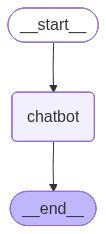

In [5]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualized as text:")
    print(app.get_graph().print_ascii())

In [6]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class MultiAgentState(TypedDict):
    # 'messages' stores the conversation history
    messages: Annotated[list, add_messages]
    # 'clarified_question' holds the output of Agent 1
    clarified_question: str

In [7]:
# Agent 1: Question Analyzer
def analyzer_node(state: MultiAgentState):
    user_input = state["messages"][-1].content
    prompt = f"Clarify and expand this question for an expert assistant: {user_input}"

    # We use the same 'chat_model' from first task
    response = chat_model.invoke(prompt)

    # We update 'clarified_question' in the state
    return {"clarified_question": response.content}

# Agent 2: Answer Generator
def generator_node(state: MultiAgentState):
    # This agent looks at the CLARIFIED version from the state
    optimized_query = state["clarified_question"]

    response = chat_model.invoke(f"Answer this query accurately: {optimized_query}")

    # We append the final answer to the message list
    return {"messages": [response]}

In [8]:
workflow = StateGraph(MultiAgentState)

# Add our two agents as nodes
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("generator", generator_node)

# Set the flow: Start -> Analyzer -> Generator -> End
workflow.add_edge(START, "analyzer")
workflow.add_edge("analyzer", "generator")
workflow.add_edge("generator", END)

# Compile
multi_agent_app = workflow.compile()

In [9]:
inputs = {"messages": [HumanMessage(content="how to loop in py")]}
for output in multi_agent_app.stream(inputs):
    for key, value in output.items():
        print(f"\n--- Output from node '{key}' ---")
        print(value)


--- Output from node 'analyzer' ---
{'clarified_question': ' An expert assistant would understand that the question "how to loop in Py" refers to requesting an explanation of how to use iteration in the Python programming language. Python provides several types of loops, including `for` loops and `while` loops, to help developers write efficient and effective code.\n\nHere\'s a more detailed explanation:\n\nIn programming, a loop is a control flow structure that allows the execution of a block of code multiple times as long as a specific condition is met. Python supports several types of loops, including `for` loops and `while` loops.\n\nA `for` loop is used when you want to iterate over a sequence (like a list, tuple or string) or an iterable object (like a dictionary or file). Here\'s the basic syntax for a `for` loop:\n\n```python\nfor variable in sequence:\n    # code to be executed\n```\n\nFor example, consider the following code that uses a `for` loop to print the numbers from 1

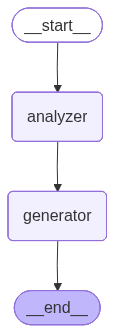

In [10]:
display(Image(multi_agent_app.get_graph().draw_mermaid_png()))

In [11]:
from typing import Annotated, TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class RouterState(TypedDict):
    messages: Annotated[list, add_messages]

# Agent 1: Python Specialist
def python_expert(state: RouterState):
    print("--- ROUTED TO PYTHON EXPERT ---")
    query = state["messages"][-1].content
    response = chat_model.invoke(f"You are a Python expert. Answer this code question: {query}")
    return {"messages": [response]}

# Agent 2: General Knowledge Specialist
def general_expert(state: RouterState):
    print("--- ROUTED TO GENERAL EXPERT ---")
    query = state["messages"][-1].content
    response = chat_model.invoke(f"You are a helpful general assistant. Answer this: {query}")
    return {"messages": [response]}

In [12]:
def route_question(state: RouterState) -> Literal["python", "general"]:
    user_input = state["messages"][-1].content.lower()

    # Simple logic to determine the path
    if "python" in user_input or "code" in user_input or "def " in user_input:
        return "python"
    else:
        return "general"

In [13]:
workflow = StateGraph(RouterState)

# 1. Add the expert nodes
workflow.add_node("python_expert", python_expert)
workflow.add_node("general_expert", general_expert)

# 2. Add the Conditional Edge (The Router)
# This starts at START and uses the router function to pick the next node
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "python": "python_expert",
        "general": "general_expert"
    }
)

# 3. Both experts lead to the end
workflow.add_edge("python_expert", END)
workflow.add_edge("general_expert", END)

# 4. Compile
router_app = workflow.compile()

In [14]:
router_app.invoke({"messages": [("user", "How do I sort a list in Python?")]})

--- ROUTED TO PYTHON EXPERT ---


{'messages': [HumanMessage(content='How do I sort a list in Python?', additional_kwargs={}, response_metadata={}, id='f3edec66-c94a-43c2-b33e-767db405b1a3'),
  AIMessage(content=" In Python, you can sort a list using the `sort()` method or the `sorted()` function. Here's how you can use both:\n\n1. Using the `sort()` method:\n\n```python\nmy_list = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]\nmy_list.sort()\nprint(my_list)\n# Output: [1, 1, 2, 3, 3, 3, 4, 5, 5, 5, 6]\n```\n\nThis method sorts the list in-place, meaning that it modifies the original list.\n\n2. Using the `sorted()` function:\n\n```python\nmy_list = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]\nsorted_list = sorted(my_list)\nprint(sorted_list)\n# Output: [1, 1, 2, 3, 3, 3, 4, 5, 5, 5, 6]\n\n# If you want to sort the list in-place using sorted() function, you can assign the result back to the original list:\nmy_list = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]\nmy_list = sorted(my_list)\nprint(my_list)\n# Output: [1, 1, 2, 3, 3, 3, 4, 5, 5, 5, 6]\n```

In [15]:
router_app.invoke({"messages": [("user", "What is the capital of France?")]})

--- ROUTED TO GENERAL EXPERT ---


{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='33fdd1b3-e3fc-4002-b0f8-1c841be01873'),
  AIMessage(content=' The capital city of France is Paris. Paris is often referred to as the "City of Light" and is one of the most famous and most visited cities in the world. It is known for its romance, art, fashion, and rich history. Some of its most famous landmarks include the Eiffel Tower, Louvre Museum, Notre Dame Cathedral, and Montmartre. Paris is located in northern France and is the country\'s most populous city.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 22, 'total_tokens': 119}, 'model_name': 'mistralai/Mistral-7B-Instruct-v0.2', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b9974-e327-7060-a84a-1c4b796f6d54-0', usage_metadata={'input_tokens': 22, 'output_tokens': 97, 'total_tokens': 119})]}

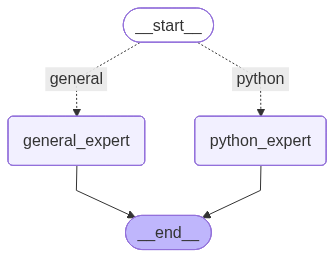

In [16]:
display(Image(router_app.get_graph().draw_mermaid_png()))